In [653]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [684]:
# Load and Prepare Data 
df = pd.read_csv('youth_data.csv')
df_processed = df.copy()

# Drop rows where the target (TOBFLAG) is missing
# TOBFLAG: 1 = has used tobacco, 0 = has not used tobacco
df = df.dropna(subset=['TOBFLAG']).copy()

In [655]:
#  Feature Engineering 
# Create a new feature representing interaction between family and school environment
df['SCHOOL_FAMILY'] = df['PARHLPHW'] * df['SCHFELT']

# Create another feature representing peer pressure or influence
df['PEER_INFLUENCE'] = df['FRDMEVR2'] * df['FRDMJMON']

In [656]:
# Define Features and Target 
# Select important predictors (based on domain understanding or correlation)
X = df[['PARHLPHW', 'SCHFELT', 'INCOME', 'SCHOOL_FAMILY',
        'PEER_INFLUENCE', 'YOGRPFT2', 'HEALTH2']]
y = df['TOBFLAG']

In [657]:
# Handle Missing Values 
# Fill missing values in the feature set using mean imputation
# This avoids removing useful rows while keeping numerical stability
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Train-Test Split 
# Spliting data into training and testing sets (80/20)
# Use stratify to maintain class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=50
)

# ----------------- Balance Classes with SMOTE -----------------
# SMOTE generates synthetic samples for the minority class
# Helps prevent model from being biased toward majority class
smote = SMOTE(random_state=50)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [658]:
# ----------------- Train Decision Tree Classifier -----------------

clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=50
)

# ----  Cross-validation before training on full set ----
from sklearn.model_selection import cross_val_score

# Perform 5-fold CV on the resampled training set
cv_scores = cross_val_score(clf, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')

print("\n Cross-Validation (5-fold) Accuracy:")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: ±{cv_scores.std():.4f}")


 Cross-Validation (5-fold) Accuracy:
Mean Accuracy: 0.7460
Standard Deviation: ±0.0134


In [659]:
# Now fit the model to full training data
clf.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, random_state=50)

In [660]:
# ----------------- Predictions & Evaluation -----------------

y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.74      0.83      1921
           1       0.19      0.64      0.30       192

    accuracy                           0.73      2113
   macro avg       0.57      0.69      0.56      2113
weighted avg       0.88      0.73      0.78      2113

Accuracy: 0.7283


<Figure size 1000x800 with 0 Axes>

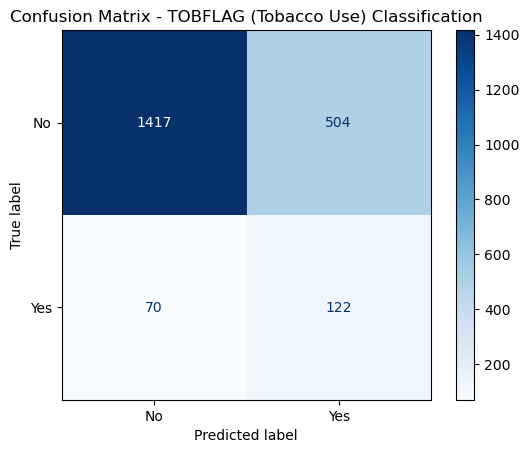

In [661]:
# ----------------- Confusion Matrix -----------------
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No", "Yes"], cmap='Blues')
plt.title("Confusion Matrix - TOBFLAG (Tobacco Use) Classification")
plt.grid(False)
plt.show()

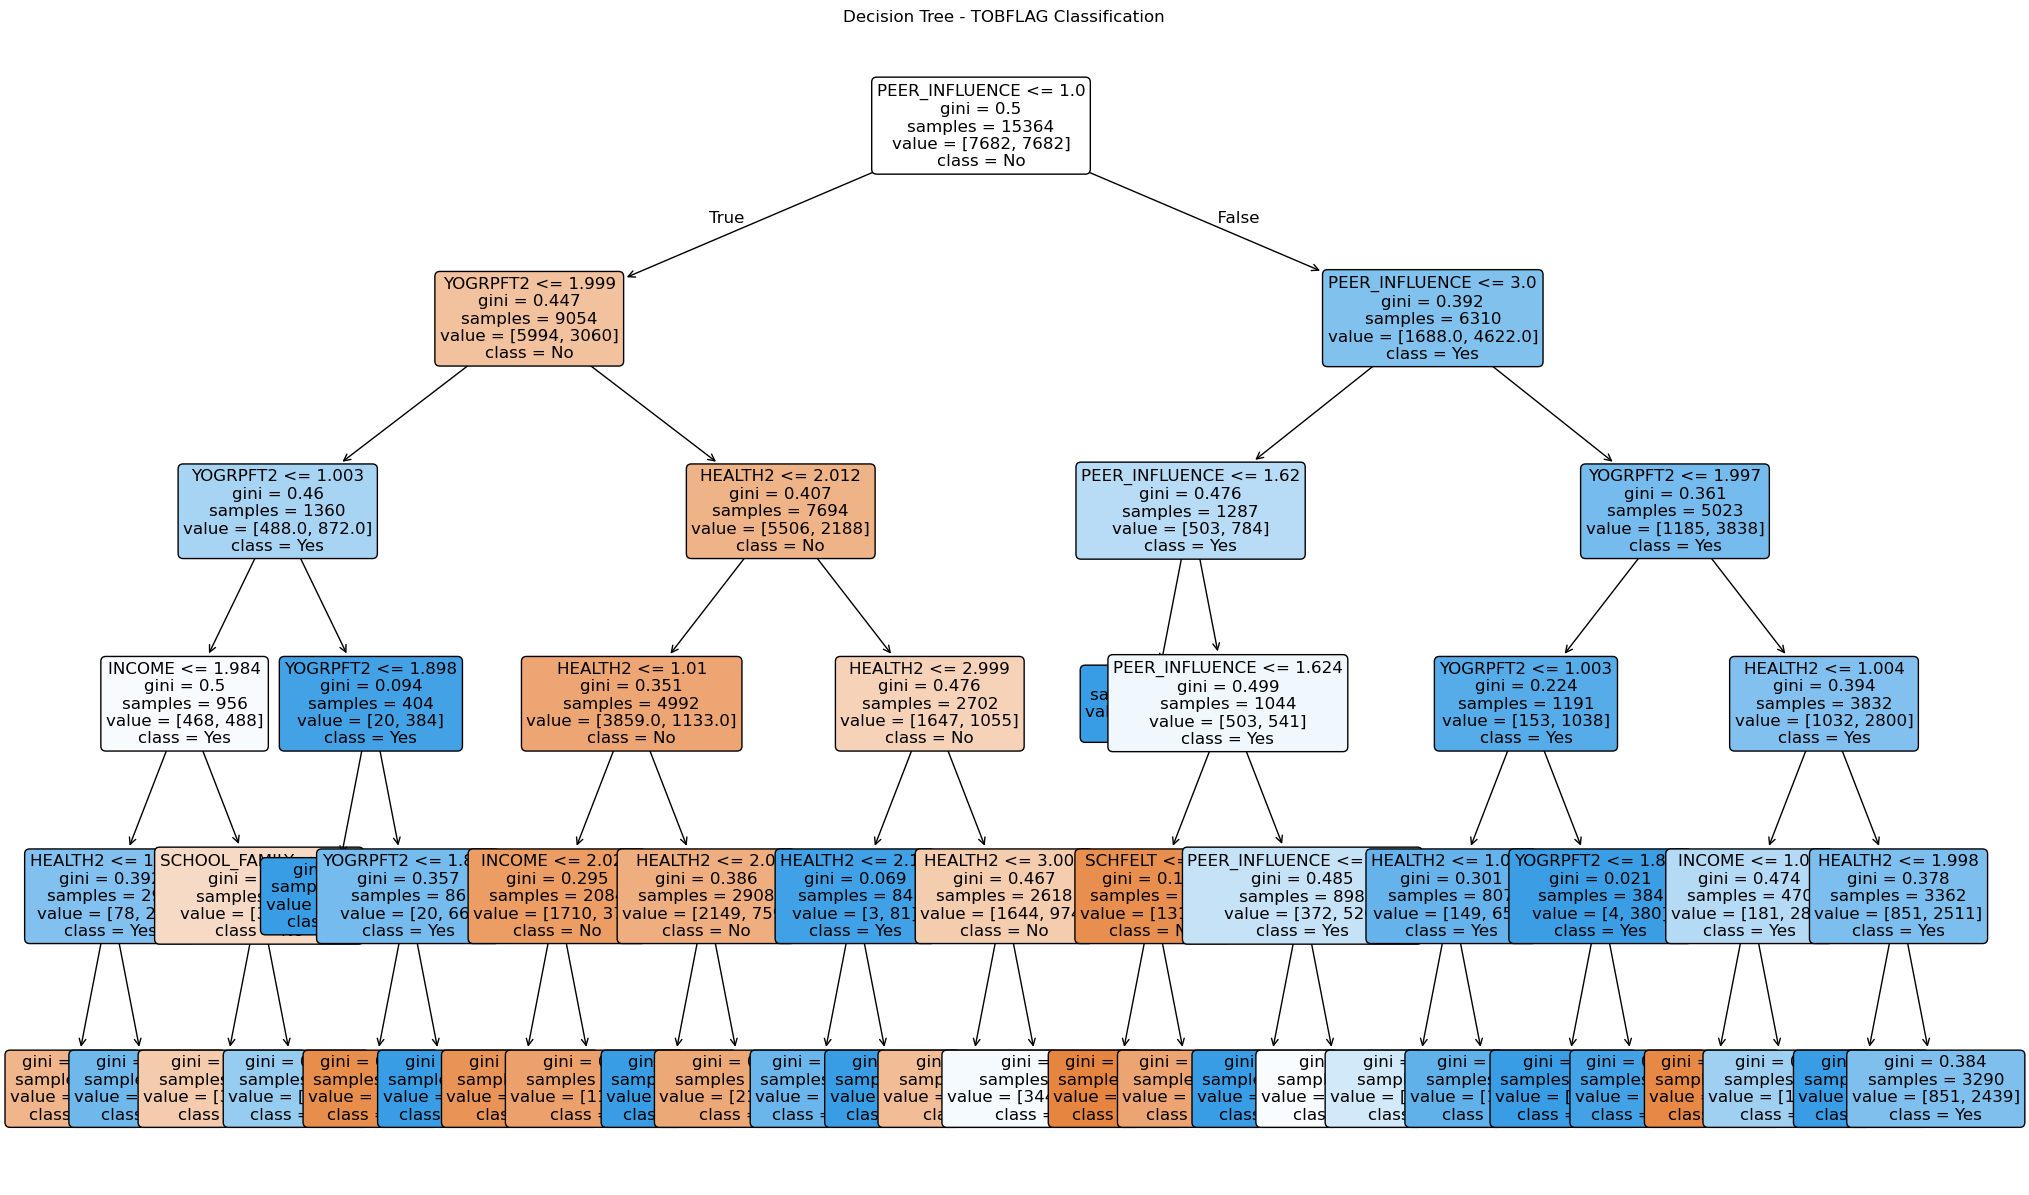


 Decision Tree Info:
Total Nodes: 55
Total Leaves: 28
Max Depth of Tree: 5


In [662]:
# ----------------- Visualize the Decision Tree -----------------
plt.figure(figsize=(25, 15))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree - TOBFLAG Classification")
plt.show()

# ----------------- Decision Tree Structure Info -----------------

# Get and print tree structure details
n_nodes = clf.tree_.node_count
n_leaves = clf.get_n_leaves()
depth = clf.get_depth()

print(f"\n Decision Tree Info:")
print(f"Total Nodes: {n_nodes}")
print(f"Total Leaves: {n_leaves}")
print(f"Max Depth of Tree: {depth}")


Feature Importance:
          Feature  Importance
4  PEER_INFLUENCE    0.603302
5        YOGRPFT2    0.209368
6         HEALTH2    0.149868
2          INCOME    0.029770
3   SCHOOL_FAMILY    0.006649
1         SCHFELT    0.001044
0        PARHLPHW    0.000000


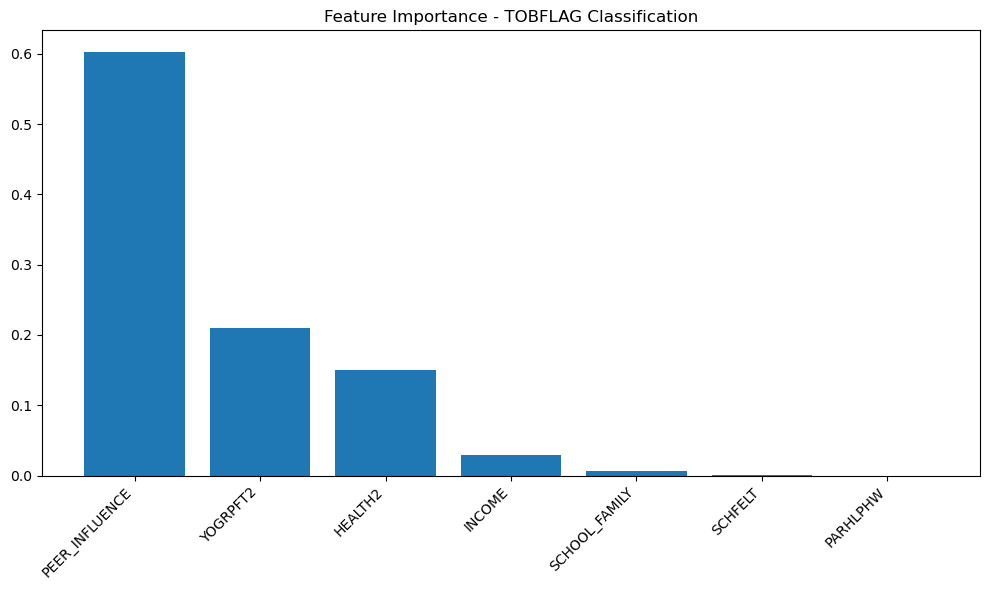

In [663]:
# ----------------- Feature Importance -----------------

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(importance['Feature'], importance['Importance'])
plt.xticks(rotation=45, ha='right')
plt.title("Feature Importance - TOBFLAG Classification")
plt.tight_layout()
plt.show()

In [686]:
# In conclusion, the binary classification model showed that juvenile tobacco use was most strongly predicted by peer influence, followed by self-rated health and young risk behaviors.  Despite the large class disparity, we were able to identify major splits and effectively explain the data by employing SMOTE and decision trees.  This approach is a useful tool for early intervention aimed at at-risk populations since it assisted in answering the question, "Has the youth used tobacco or not?"

